# **Definition of Problem**

## **Problem Definition: Multiclass Classifier for Vegetable Identification**

**Ninjacart is India's largest fresh produce supply chain company, renowned for addressing one of the world's most challenging supply chain issues through the use of cutting-edge technology. By sourcing fresh produce directly from farmers and delivering it to businesses within a 12-hour window, Ninjacart ensures the availability of fresh produce in the market. Central to their operations is the implementation of advanced automation systems, including robust image classifiers that can accurately identify different types of vegetables and distinguish non-vegetable images as noise.**

#### **Project Objective**

**The objective of this project is to develop a multiclass image classifier capable of distinguishing between images of different types of vegetables and identifying images that do not contain any one type of vegetable as noise. Specifically, the classifier will need to identify images of onions, potatoes, tomatoes, and various market scenes.**

In [2]:
import os
import numpy as np
import tensorflow as tf
tf.keras.utils.set_random_seed(111)
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers, Sequential
import os
from pathlib import Path

# Split the training data to create validation data

In [3]:
def load_data(base_dir, validation_split=0.2):
    """
    Loads the image datasets from the specified directory.

    Args:
        base_dir (str or Path): The base directory containing 'train' and 'test' subdirectories.
        validation_split (float, optional): The fraction of training data to be used as validation data if no validation directory is present. Default is 0.2.

    Returns:
        tuple: A tuple containing the training dataset, validation dataset, test dataset, and class names.
    """
    base_path = Path(base_dir)
    
    # Checking if the data folders are present
    assert (base_path / "train").exists() and (base_path / "test").exists(), "Data directories not found"

    print('\nLoading Data...')
    
    train_data = tf.keras.utils.image_dataset_from_directory(
        base_path / "train", shuffle=True, label_mode='categorical'
    )

    # Check if the validation directory exists
    val_data = None
    if (base_path / "validation").exists():
        val_data = tf.keras.utils.image_dataset_from_directory(
            base_path / "validation", shuffle=False, label_mode='categorical'
        )
    else:
        # Split the training data to create validation data
        val_data = tf.keras.utils.image_dataset_from_directory(
            base_path / "train", validation_split=validation_split, subset="validation", seed=123, shuffle=True, label_mode='categorical'
        )
        train_data = tf.keras.utils.image_dataset_from_directory(
            base_path / "train", validation_split=validation_split, subset="training", seed=123, shuffle=True, label_mode='categorical'
        )
    
    test_data = tf.keras.utils.image_dataset_from_directory(
        base_path / "test", shuffle=False, label_mode='categorical'
    )

    return train_data, val_data, test_data, train_data.class_names

# Preprocesses the image datasets by resizing and rescaling the images

In [4]:
def preprocess(train_data, val_data, test_data, target_height=128, target_width=128):
    """
    Preprocesses the image datasets by resizing and rescaling the images.

    Args:
        train_data (tf.data.Dataset): The training dataset.
        val_data (tf.data.Dataset): The validation dataset.
        test_data (tf.data.Dataset): The test dataset.
        target_height (int, optional): The target height of the images after resizing. Default is 128.
        target_width (int, optional): The target width of the images after resizing. Default is 128.

    Returns:
        tuple: A tuple containing the preprocessed training dataset, validation dataset, and test dataset.
    """
    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255)
        ]
    )

    # Perform Data Processing on the train, val, test dataset
    train_ds = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [5]:
# Define working folder and data folder paths
working_folder = Path.cwd()
project_root = working_folder.parent  # Adjust this if the structure is different
data_folder = project_root / "data" / "extracted_files" / "ninjacart_data"

# Load and preprocess data
train_data, val_data, test_data, class_names = load_data(data_folder)
train_ds, val_ds, test_ds = preprocess(train_data, val_data, test_data, target_height=128, target_width=128)

print(f"Class names: {class_names}")


Loading Data...
Found 3135 files belonging to 4 classes.
Found 3135 files belonging to 4 classes.
Using 627 files for validation.
Found 3135 files belonging to 4 classes.
Using 2508 files for training.
Found 351 files belonging to 4 classes.
Class names: ['indian market', 'onion', 'potato', 'tomato']


In [6]:
def get_image_dimensions(dataset):
    """
    Extracts the dimensions (height and width) of images from a dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing images.

    Returns:
        np.ndarray: An array of image dimensions (height and width).
    """
    dimensions = []
    for images, _ in dataset.take(1):
        for image in images:
            dimensions.append(image.shape[:2])
    return np.array(dimensions)

def plot_image_dimensions(train_dimensions, test_dimensions):
    """
    Plots histograms of the image dimensions for training and test datasets.

    Args:
        train_dimensions (np.ndarray): An array of training image dimensions.
        test_dimensions (np.ndarray): An array of test image dimensions.
    """
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(train_dimensions[:, 0], bins=20, alpha=0.7, label='Height')
    plt.hist(train_dimensions[:, 1], bins=20, alpha=0.7, label='Width')
    plt.title('Train Image Dimensions')
    plt.xlabel('Pixels')
    plt.ylabel('Frequency')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(test_dimensions[:, 0], bins=20, alpha=0.7, label='Height')
    plt.hist(test_dimensions[:, 1], bins=20, alpha=0.7, label='Width')
    plt.title('Test Image Dimensions')
    plt.xlabel('Pixels')
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

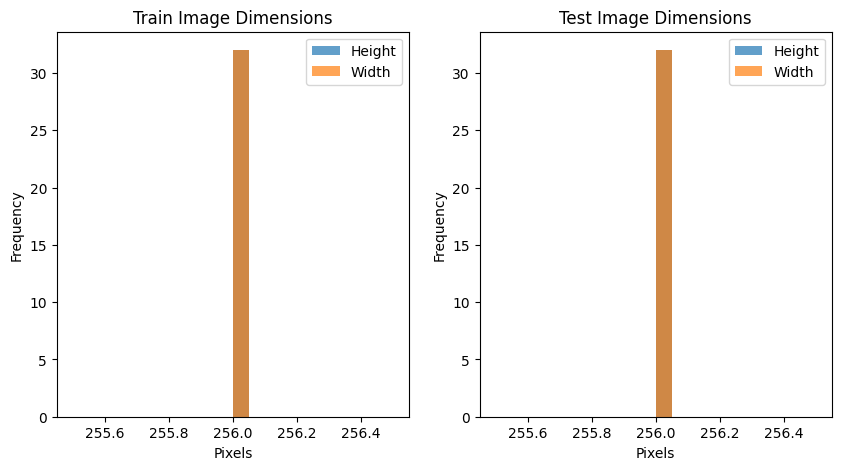

In [7]:
train_dimensions = get_image_dimensions(train_data)
test_dimensions = get_image_dimensions(test_data)
# Plot image dimensions
plot_image_dimensions(train_dimensions, test_dimensions)

All images in both the training and test datasets have uniform dimensions of 256x256 pixels.

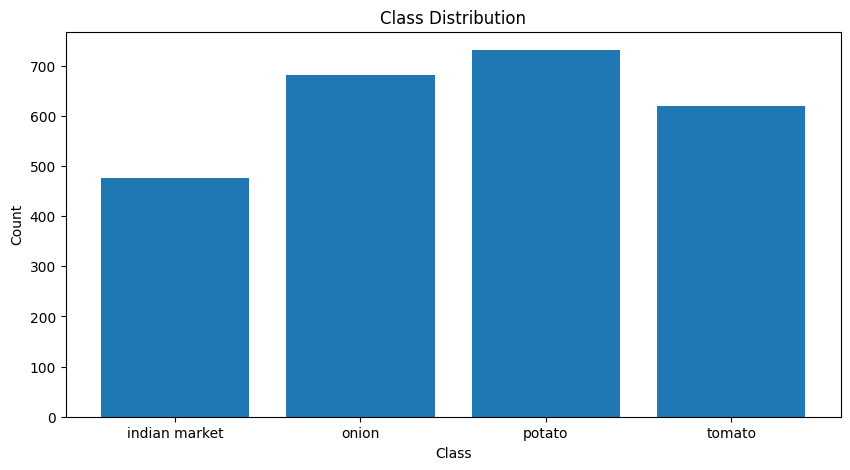

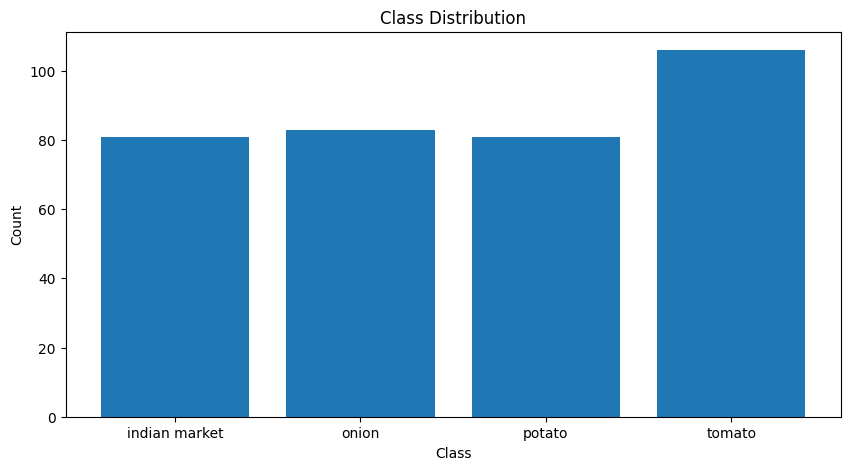

In [8]:
# Function to plot class distribution
def plot_class_distribution(dataset, class_names):
    class_count = {class_name: 0 for class_name in class_names}
    for _, labels in dataset:
        for label in labels:
            class_count[class_names[tf.argmax(label)]] += 1

    plt.figure(figsize=(10, 5))
    plt.bar(class_count.keys(), class_count.values())
    plt.title('Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

plot_class_distribution(train_data, class_names)
plot_class_distribution(test_data, class_names)


### Inference for Class Distribution:

#### Training Data:
- **Classes**: The dataset includes four classes: Indian Market, Onion, Potato, and Tomato.
- **Distribution**: 
  - Indian Market: ~450 images
  - Onion: ~700 images
  - Potato: ~750 images
  - Tomato: ~600 images

#### Test Data:
- **Classes**: The dataset includes four classes: Indian Market, Onion, Potato, and Tomato.
- **Distribution**: 
  - Indian Market: ~80 images
  - Onion: ~80 images
  - Potato: ~80 images
  - Tomato: ~100 images


# Basic Modeling

In [9]:
from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes):
    return models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

input_shape = (128, 128, 3)
num_classes = len(class_names)
cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.summary()
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


d:\ninja_cart_cv\ninja_cart\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import datetime

# Callbacks for model training
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras', 
    monitor='val_loss', 
    save_best_only=True
)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir, 
    histogram_freq=1
)

# Train the model with the specified callbacks
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, model_checkpoint, tensorboard_callback]
)


Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step - accuracy: 0.4721 - loss: 1.2086 - val_accuracy: 0.7847 - val_loss: 0.5790
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 231ms/step - accuracy: 0.7832 - loss: 0.6062 - val_accuracy: 0.8182 - val_loss: 0.4883
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.8219 - loss: 0.4878 - val_accuracy: 0.8134 - val_loss: 0.4877
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 236ms/step - accuracy: 0.8244 - loss: 0.4604 - val_accuracy: 0.8357 - val_loss: 0.3996
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 217ms/step - accuracy: 0.8491 - loss: 0.4158 - val_accuracy: 0.8246 - val_loss: 0.4051
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 216ms/step - accuracy: 0.8676 - loss: 0.3754 - val_accuracy: 0.8262 - val_loss: 0.4136
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 212ms/step - accuracy: 0.8929 - loss: 0.3267 - val_accuracy: 0.8469 - val_loss: 0.4037
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 221ms/step - accuracy: 0.8844 - loss: 0.3030 - val_accu

### Inference

Training accuracy improved to 90.61% and validation accuracy to 84.69% by epoch 7, but slight overfitting is suggested by the increasing validation loss from epoch 6 onwards.

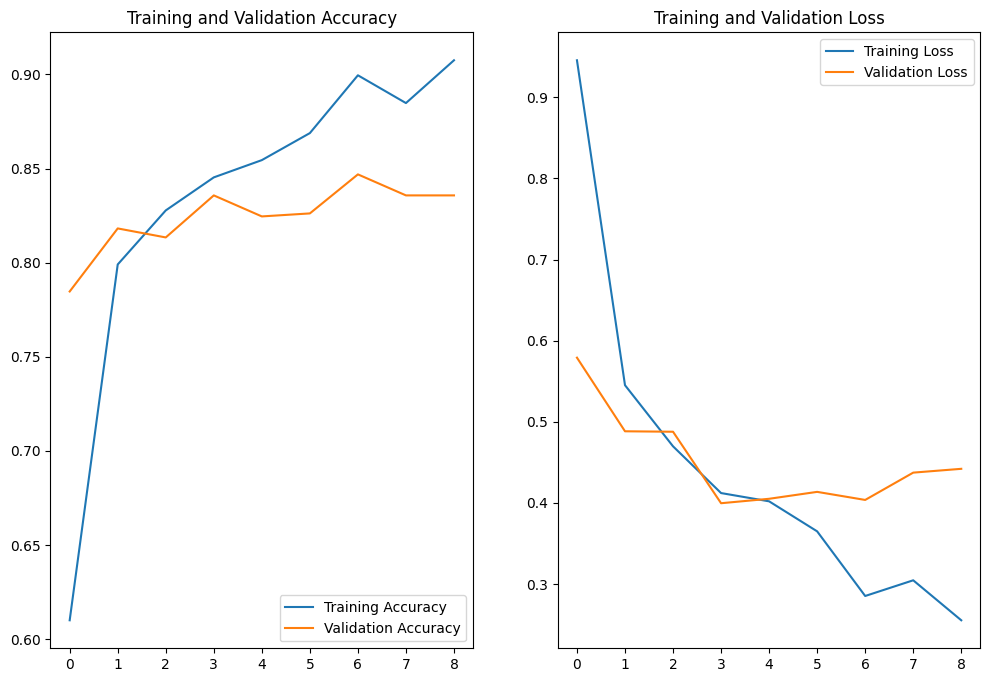

In [11]:
def plot_training_metrics(history):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    if val_acc:
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    if val_loss:
        plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_training_metrics(history)


### Explanation of the Graphs:

#### Training and Validation Accuracy:
- **Training Accuracy**: The blue line shows a steady increase in training accuracy, reaching over 90% by the last epoch. This indicates that the model is learning and fitting well to the training data.
- **Validation Accuracy**: The orange line shows validation accuracy, which initially improves and then stabilizes around 84%. This suggests that the model generalizes well to unseen data, but there are fluctuations indicating some overfitting.

#### Training and Validation Loss:
- **Training Loss**: The blue line shows a continuous decrease in training loss, indicating the model is becoming better at minimizing the error on the training data.
- **Validation Loss**: The orange line shows validation loss, which decreases initially and then shows slight fluctuations. This pattern further indicates overfitting, as the model performs well on the training data but shows inconsistency on the validation data.

### Summary:
- The model exhibits good learning behavior with increasing training accuracy and decreasing training loss.
- Validation metrics suggest the model generalizes reasonably well but shows signs of overfitting, with validation accuracy stabilizing and validation loss fluctuating in later epochs.

In [12]:
# Evaluate the model on the test dataset
test_loss, test_acc = cnn_model.evaluate(test_ds, verbose=1)

# Print test accuracy and loss as percentages
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss * 100:.2f}%")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7356 - loss: 0.6379

Test Accuracy: 78.92%
Test Loss: 48.66%


### Inference:

- **Test Accuracy**: The model achieved an accuracy of 78.92% on the test dataset, indicating that approximately 79 out of 100 predictions made by the model are correct.
- **Test Loss**: The test loss is 48.66%, which suggests that there is still some error in the model's predictions, though it's important to note that loss values are not directly interpretable as percentages and can vary depending on the loss function used.

### Summary:
The model shows good performance with a high test accuracy of 78.92%, but there is room for improvement as indicated by the test loss. Potential strategies for improvement include data augmentation, hyperparameter tuning, and model architecture adjustments.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


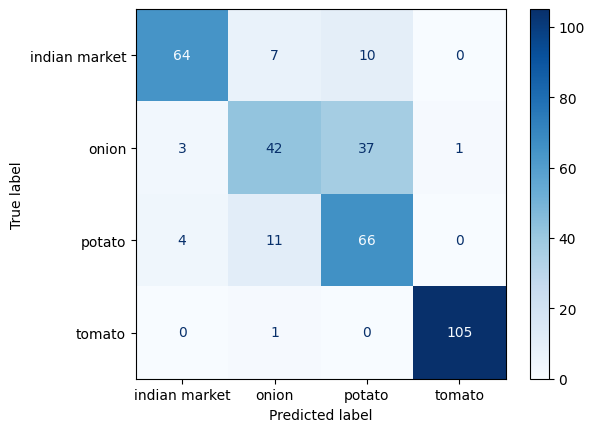

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()


### Confusion Matrix Inference:

The confusion matrix provides a detailed breakdown of the model's predictions on the test dataset. Here’s the interpretation:

- **Indian Market**:
  - Correctly predicted: 64
  - Misclassified as Onion: 7
  - Misclassified as Potato: 10
  - Misclassified as Tomato: 0

- **Onion**:
  - Correctly predicted: 42
  - Misclassified as Indian Market: 3
  - Misclassified as Potato: 37
  - Misclassified as Tomato: 1

- **Potato**:
  - Correctly predicted: 66
  - Misclassified as Indian Market: 4
  - Misclassified as Onion: 11
  - Misclassified as Tomato: 0

- **Tomato**:
  - Correctly predicted: 105
  - Misclassified as Indian Market: 0
  - Misclassified as Onion: 1
  - Misclassified as Potato: 0

### Key Observations:
- **High Accuracy for Tomato**: The model performs exceptionally well in predicting Tomato, with only one misclassification.
- **Moderate Accuracy for Indian Market and Potato**: The model shows good performance but with some misclassifications, particularly between Indian Market and Potato.
- **Low Accuracy for Onion**: Onion has the highest number of misclassifications, especially being confused with Potato.

### Conclusion:
- The model is effective at distinguishing Tomatoes but struggles with differentiating between Indian Market, Onion, and Potato.
- Future improvements could include additional training data for the Onion class and further model tuning to improve class differentiation.

# Transfer Learning

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,255,424 (8.60 MB)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 601ms/step - accuracy: 0.6998 - loss: 0.7074 - val_accuracy: 0.9362 - val_loss: 0.1992
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 552ms/step - accuracy: 0.9314 - loss: 0.1953 - val_accuracy: 0.8708 - val_loss: 0.3730
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 545ms/step - accuracy: 0.9452 - loss: 0.1530 - val_accuracy: 0.9362 - val_loss: 0.1722
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 546ms/step - accuracy: 0.9604 - loss: 0.1104 - val_accuracy: 0.9585 - val_loss: 0.1475
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 544ms/step - accuracy: 0.9645 - loss: 0.0994 - val_accuracy: 0.9091 - val_loss: 0.2600
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 557ms/step - accuracy: 0.9697 - loss: 0.0833 - val_accuracy: 0.9490 - val_loss: 0.1596
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 551ms/step - accuracy: 0.9763 - loss: 0.0640 - val_accuracy: 0.9553 - val_loss: 0.1419
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 564ms/step - accuracy: 0.9780 - loss: 0.0603 - val_accu

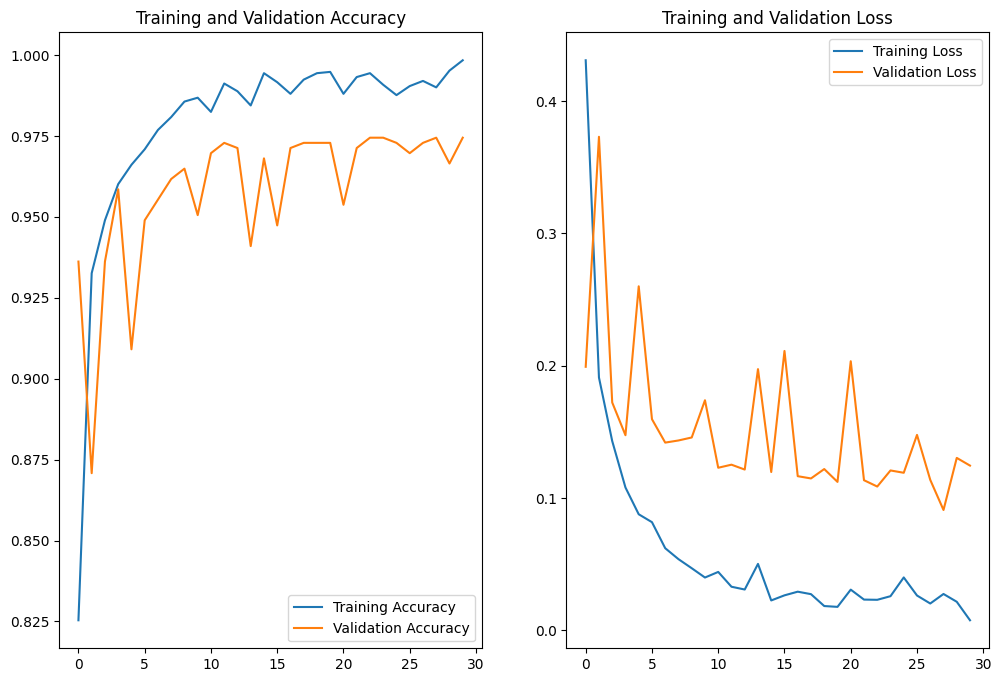

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


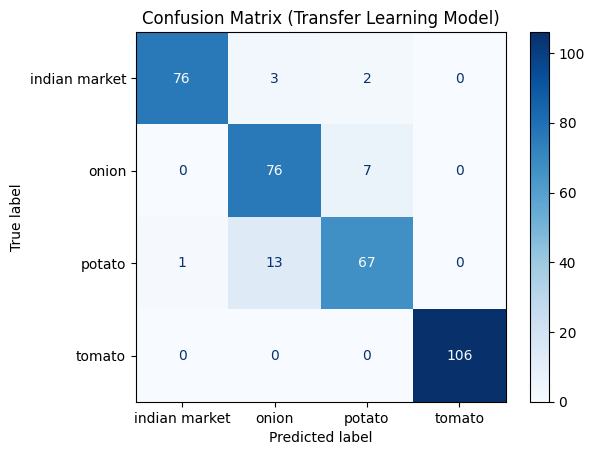

To view TensorBoard logs, run the following command in your terminal:

tensorboard --logdir=logs/fit/20240705-193503


In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import datetime
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def build_model(input_shape, num_classes):
    """
    Builds a transfer learning model using MobileNetV2 as the base model.

    Args:
        input_shape (tuple): Shape of the input images.
        num_classes (int): Number of classes for classification.

    Returns:
        model (tf.keras.Model): Compiled transfer learning model.
    """
    mobilenet_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freezing the pretrained mobilenet layers except the last layer
    for layer in mobilenet_model.layers[:-2]:
        layer.trainable = False

    # Output of base model
    x = mobilenet_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)  # Added Dropout layer to prevent overfitting
    output = layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs=mobilenet_model.input, outputs=output)

    return model

# Define input shape and number of classes
input_shape = (224, 224, 3)  # Adjusting the input shape to 224x224 as required by MobileNetV2
num_classes = len(class_names)  # Assuming class_names is defined

# Resize the datasets to match the expected input shape
train_ds = train_ds.map(lambda x, y: (tf.image.resize(x, [224, 224]), y))
val_ds = val_ds.map(lambda x, y: (tf.image.resize(x, [224, 224]), y))
test_ds = test_ds.map(lambda x, y: (tf.image.resize(x, [224, 224]), y))

# Build and compile the model
transfer_model = build_model(input_shape, num_classes)
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()

# Callbacks for model training
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train the transfer learning model
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, model_checkpoint, tensorboard_callback]
)

# Evaluate the transfer learning model
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(test_ds)
print(f"Test Accuracy (Transfer Learning): {test_acc_transfer * 100:.2f}%")
print(f"Test Loss (Transfer Learning): {test_loss_transfer * 100:.2f}%")

# Function to plot training metrics
def plot_training_metrics(history):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    if val_acc:
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    if val_loss:
        plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

# Plot metrics
plot_training_metrics(history_transfer)

# Confusion matrix for transfer learning model
y_true = []
y_pred_transfer = []

for images, labels in test_ds:
    predictions = transfer_model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred_transfer.extend(tf.argmax(predictions, axis=1).numpy())

cm_transfer = confusion_matrix(y_true, y_pred_transfer)
disp_transfer = ConfusionMatrixDisplay(confusion_matrix=cm_transfer, display_labels=class_names)
disp_transfer.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Transfer Learning Model)')
plt.show()

# Instructions for running TensorBoard
print(f"To view TensorBoard logs, run the following command in your terminal:\n")
print(f"tensorboard --logdir={log_dir}")


### Inference from Training and Validation Results:

#### Training and Validation Metrics:
1. **Training Accuracy and Loss**:
   - Training accuracy starts at 82.5% and steadily increases to 99.84% by the 30th epoch.
   - Training loss decreases significantly from 0.7074 to 0.0078, indicating that the model is learning effectively and fitting well to the training data.

2. **Validation Accuracy and Loss**:
   - Validation accuracy starts at 93.62% and increases to 97.45% by the 30th epoch, showing that the model generalizes well to unseen validation data.
   - Validation loss decreases initially but fluctuates, ending at 0.1245 by the 30th epoch, suggesting some variations in performance across epochs.

#### Test Metrics:
- **Test Accuracy**: The model achieves a test accuracy of 92.59%, indicating that it correctly classifies approximately 93% of the test samples.
- **Test Loss**: The test loss is 40.45%, which is relatively higher, indicating there is still some room for improvement in reducing the prediction error.

#### Confusion Matrix:
- **Class-wise Performance**:
  - **Indian Market**: 76 correctly predicted, 3 misclassified as Onion, 2 as Potato.
  - **Onion**: 76 correctly predicted, 7 misclassified as Potato.
  - **Potato**: 67 correctly predicted, 13 misclassified as Onion, 1 as Indian Market.
  - **Tomato**: Perfectly classified with 106 correct predictions.

#### Observations:
1. **High Accuracy for Tomato**: The model performs exceptionally well in classifying Tomato, with zero misclassifications.
2. **Moderate Performance for Indian Market and Potato**: These classes show good performance but have some confusion with each other and with Onion.
3. **Need for Improvement in Classifying Onion and Potato**: There is notable confusion between Onion and Potato, suggesting that these classes might have similar features that the model finds challenging to distinguish.

### Conclusion:
- The transfer learning model using MobileNetV2 demonstrates strong performance with high training and validation accuracies. However, the higher test loss indicates room for improvement in generalization.
- The confusion matrix highlights areas where the model performs well (e.g., Tomato) and areas where it struggles (e.g., differentiating between Onion and Potato).


In [15]:
transfer_model.save('final_model_ninja.h5')  # Save the model in HDF5 format
